# Cosmic Skyscraper Tomography

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq, root_scalar, curve_fit
import seaborn as sns
from matplotlib.animation import FuncAnimation, FFMpegWriter

# Diseño de los gráficos
sns.set()
sns.set_context("paper")
sns.set_palette("colorblind")

Differential flux of muons:

\begin{equation*}
    \Phi_0 = \frac{dN(E_0, \theta)}{dE_0}
\end{equation*}

Integrated flux of muons:

\begin{equation*}
    I[\varrho, \theta] = \int_{E_{min}}^{\infty}\Phi(E_0, \theta) dE_0(\text{cm}^2\text{sr}^{-1}\text{s}^{-1})
\end{equation*}

Minimum initial energy necessary for a muon to cross a given opacity $\varrho_L$:
\begin{equation*}
    E_{min} = E_{\mu} + \int_{0}^{\varrho_L} \frac{dE}{d\varrho} d\varrho
\end{equation*}

Opacity:
\begin{equation*}
    \varrho(L) = \int_L \rho(\xi)d\xi
\end{equation*}

Since we are assuming that the density of the material is constant, then the opacity is given by:

\begin{equation}
    \varrho = \rho \cdot L
\end{equation}

For standard rock, the following expression holds with a relative error of $2\%$.

\begin{equation*}
    \frac{dE}{d\varrho} = -10^{l_4y^4 + l_3y^3 + l_2y^2 + l_1y + l_0}
\end{equation*}

\begin{align*}
    y &= \log (E), \quad \text{$E$ in GeV,} \\
    l_0 &= 0.2549 \\
    l_1 &= 0.081 \\
    l_2 &= 0.0368 \\
    l_3 &= -0.0461 \\
    l_4 &= 0.0154
\end{align*}

The density of standard rock is $\rho_{sr} = 2650 \text{ kg m}^{-3}$.

\begin{equation*}
    E_{\mu} = 0.10566 \text{ GeV}.
\end{equation*}

Since we do not have an expression for the $E = E(\varrho)$, it isn't possible to calculate directly $E_{min}$. However, it can be calculated numericaly given the following expression:
\begin{equation}
    \varrho_L = \int_{E_\mu}^{E_{min}} \frac{d\varrho}{dE}dE = \rho \cdot L
\end{equation}

Since we alreade have $\varrho_L$, the $E_{min}$ has to be such that the integral gives that value.

Models for differential flux of muons:

Gaisser (1990):
\begin{equation*}
    \Phi_G(E_0, \theta) = A_G E_0^{-\gamma} \left( \frac{1}{1 + \hat{E}_0\cos(\theta) / E_{0,\pi}^{cr}} + \frac{B_G}{1 + \hat{E}_0 \cos(\theta) / E_{0,K}^{cr}} + r_c \right)
\end{equation*}

where
\begin{align*}
    \text{Scale factor:} & \quad A_G = 0.1258 \\
    \text{Balance factor:} & \quad B_G = 0.0588 \\
    \text{Power index:} & \quad \gamma = 2.65 \\
    \text{Critical energy pions:} & \quad E_{0, \pi}^{cr} = 100 \\
    \text{Critical energy kaons:} & \quad E_{0, K}^{cr} = 650 \\
    \text{Ratio prompt muons to pions:} & \quad r_c = 0
\end{align*}

Bugaev (1998):

\begin{equation*}
    \Phi_B(p) = A_Bp^{-(\alpha_3y^3 + \alpha_2y^2 + \alpha_1y + \alpha_0)}
\end{equation*}

where
\begin{align*}
    p^2c^2 &= E_0^2 - E_\mu^2 \\
    E_\mu &= 0.10566 \text{ GeV} \\
    c &= 1 \\
    y &= \log_{10}(p)
\end{align*}

Hebbecker (2002):

\begin{equation*}
    \Phi_H(p) = A_H10^{H(y)}
\end{equation*}

where
\begin{align*}
    H(y) &= h_1\frac{y^3 - 5y^2 + 6y}{2} + h_2\frac{-2y^3 + 9y^2 - 10y + 3}{3} + h_3\frac{y^3 - 3y^2 + 2y}{6} + s_2\frac{y^3 - 6y^2 + 11y - 6}{3} \\
    y &= \log_{10}(p) \\
    h_1 &= 0.144 \\
    h_2 &= -2.51 \\
    h_3 &= -5.76 \\
    s_2 &= 2.22
\end{align*}

Reyna/Bugaev (1998):
\begin{equation*}
    \Phi_{RB}(p, \theta) = \cos^3(\theta)\Phi_B(p\cos(\theta))
\end{equation*}

where
\begin{align*}
    A_R &= 0.00253 \\
    \alpha_0 &= 0.2455 \\
    \alpha_1 &= 1.288 \\
    \alpha_2 &= -0.2555 \\
    \alpha_3 &= 0.0209
\end{align*}

Reyna/Hebbeker
\begin{equation*}
    \Phi_{RH}(p, \theta) = \cos^3(\theta)\Phi_H(p\cos(\theta))
\end{equation*}

Altitude correction:
\begin{align*}
    \frac{\Phi(h)}{\Phi(h=0)} &= e^{-h/h_0} \\
    h_0 &= 4900 + 750p
\end{align*}

where $p$ is the momentum of the muon in GeV.

In [3]:
# Muon rest energy (GeV)
E_mu = 0.10566

# Density of standar rock (g/cm^3)
rho_sr = 2.65

# dE/dvarrho for standard rock (Parametrization in MeV g^-1 cm^2)
def dE_dvarrho_sr(E):
    l0 = 0.2549
    l1 = 0.081
    l2 = 0.0368
    l3 = -0.0461
    l4 = 0.0154
    y = np.log10(E)

    return -10**(l4*y**4 + l3*y**3 + l2*y**2 + l1*y + l0) / 1000.0

def dvarrho_dE(E):
        return 1 / np.abs(dE_dvarrho_sr(E))

#
def Emin(L):
    def f(Emin):
        integral, error = quad(dvarrho_dE, E_mu, Emin)
        return rho_sr * (L * 100.0) - integral

    sol = root_scalar(f,bracket=[E_mu + 1e-3, 1e5], method='brentq')

    return sol.root

# Gaisser model
def Gaisser(E, theta, h):
    # Parameters from model MS1 (Gaisser)
    Ag = 0.1258
    Bg = 0.0588
    gamma = 2.56
    Ecr_pi = 100.0
    Ecr_K = 650.0
    rc = 0

    # Flux at sea level
    Phi_G = Ag * E**(-gamma) * (1 / (1 + E * np.cos(theta) / Ecr_pi) + Bg / (1 + E * np.cos(theta) / Ecr_K) + rc)

    # Altitude correction
    p = np.sqrt(E**2 - E_mu**2)
    h0 = 4900 + 750 * p
    h_corr = np.exp(-h / h0)

    return Phi_G * h_corr

# Reyna/Bugaev model ----> CAREFUL ----> this model works for SEA LEVEL ENERGY!
def ReynaBugaev(E, theta, h):

    p = np.sqrt(E**2 - E_mu**2)
    Ab = 0.00253
    a0 = 0.2455
    a1 = 1.288
    a2 = -0.2555
    a3 = 0.0209

    pcos = p*np.cos(theta)
    y = np.log10(pcos)

    phi_B = Ab*(pcos**(-(a3*y**3 + a2*y**2 + a1*y + a0)))

    # Flux at sea level
    Phi_RB = (np.cos(theta)**3) * phi_B

    # Altitude correction
    h0 = 4900 + 750 * p
    h_corr = np.exp(-h / h0)

    return Phi_RB * h_corr

# Reyna/Hebbeker model
def ReynaHebbeker(E, theta, h):

    p = np.sqrt(E**2 - E_mu**2)
    y = np.log10(p * np.cos(theta))

    Ah = 0.00253
    h1 = 0.144
    h2 = -2.51
    h3 = -5.76
    s2 = -2.22  # corrección en https://gmd.copernicus.org/articles/15/2441/2022/

    H = h1*(y**3-5*y**2+6*y)/2 + h2*(-2*y**3+9*y**2-10*y+3)/3 + h3*(y**3-3*y**2+2*y)/6 +s2*(y**3-6*y**2+11*y-6)/3
    Phi_H = Ah * 10**H

    # Flux at sea level
    Phi_RH = np.cos(theta)**3 * Phi_H

    # Altitude correction
    h0 = 4900 + 750 * p
    h_corr = np.exp(-h / h0)

    return Phi_RH * h_corr


# Integrate the differential flux with respect to the energy, from the minimum energy to infinity
def Integrate_flux(dif_flux, Emin, theta, h):
    I, _ = quad(dif_flux, Emin, np.inf, args=(theta, h))

    return I

Gaisser correction for large angles (this doesn't change much), and Gaisser/Tang

In [4]:
# Muon rest energy (GeV)
E_mu = 0.10566

# Density of standar rock (g/cm^3)
rho_sr = 2.65

# dE/dvarrho for standard rock (Parametrization in MeV g^-1 cm^2)
def dE_dvarrho_sr(E):
    l0 = 0.2549
    l1 = 0.081
    l2 = 0.0368
    l3 = -0.0461
    l4 = 0.0154
    y = np.log10(E)

    return -10**(l4*y**4 + l3*y**3 + l2*y**2 + l1*y + l0) / 1000.0

def dvarrho_dE(E):
        return 1 / np.abs(dE_dvarrho_sr(E))

#
def Emin(L):
    def f(Emin):
        integral, error = quad(dvarrho_dE, E_mu, Emin)
        return rho_sr * (L * 100.0) - integral

    sol = root_scalar(f,bracket=[E_mu + 1e-3, 1e5], method='brentq')

    return sol.root

def cos_theta_corr(theta):
    RE = 6370.0
    h_atm = 15.0

    return np.sqrt(1-((1-np.cos(theta)**2)/(1+h_atm/RE)**2))

def E_hat(E, theta):
    coscorr = cos_theta_corr(theta)
    dE0 = 0.00206*(1030/coscorr - 120)
    return E + dE0

# Gaisser corrected
def Gaisser_corrected(E, theta, h):

    Ag = 0.1258
    Bg = 0.0588
    gamma = 2.65
    Ecr_pi = 100.0
    Ecr_K = 650.0
    rc = 0

    coscorr = cos_theta_corr(theta)
    Ehat = E_hat(E, theta)

    Phi_G = Ag*E**(-gamma)*(1/(1+E*coscorr/Ecr_pi) + Bg/(1+E*coscorr/Ecr_K) + rc)

    p = np.sqrt(E**2 - E_mu**2)
    h0 = 4900 + 750 * p
    h_corr = np.exp(-h / h0)

    return Phi_G * h_corr


# Gaisser/Tang
p1 = 0.102573
p2 = -0.068287
p3 = 0.958633
p4 = 0.0407253
p5 = 0.817285

def cos_thetang(theta):
    x = np.cos(theta)
    num = (x**2+p1**2+p2*x**p3+p4*x**p5)
    denom = (1 + p1**2 + p2 + p4)
    return np.sqrt(num / denom)

def modified_params(E0, theta):

    E0 = np.asarray(E0)
    ctt = cos_thetang(theta)

    cond1 = E0 > 100/ctt
    cond2 = (E0 < 100/ctt) & (E0 > 1/ctt)
    cond3 = E0 < 1/ctt

    E_hat = np.zeros_like(E0)
    AT = np.zeros_like(E0)
    rc = np.zeros_like(E0)

    # 1st region
    E_hat = np.where(cond1, E0, E_hat)
    AT = np.where(cond1, 1.0, AT)
    rc = np.where(cond1, 0.0, rc)

    # 2nd region
    AT_val = 1.1*((90*np.sqrt(ctt - 0.001)) / 1030)**(4.5/(E0*ctt))
    Delta = 2.06e-3 * (950/ctt - 90)

    E_hat = np.where(cond2, E0 + Delta, E_hat)
    AT = np.where(cond2, AT_val, AT)
    rc = np.where(cond2, 1e-4, rc)

    # 3rd region
    E_hat_low = (3*E0 + 7*(1/ctt))/10.0

    E_hat = np.where(cond3, E_hat_low, E_hat)
    AT = np.where(cond3, AT_val, AT)
    rc = np.where(cond3, 1e-4, rc)

    return E_hat, AT, rc


# def modified_params(E0, theta):

#     ctt = cos_thetang(theta)

#     if E0 > 100 / ctt:
#         AT = 1.0
#         rc = 0.0
#         E_hat = E0

#     elif 1/ctt < E0 < 100/ctt:

#         Delta = 2.06e-3 * (950/ctt - 90)
#         E_hat = E0 + Delta

#         rc = 1e-4
#         AT = 1.1*((90*np.sqrt(ctt - 0.001)) / 1030)**(4.5/(E0*ctt))

#     elif 1/ctt > E0:

#         E_hat = (3*E0 - 7*(1/ctt))/10.0

#         rc = 1e-4
#         AT = 1.1*((90*np.sqrt(ctt - 0.001)) / 1030)**(4.5/(E0*ctt))

#     return E_hat, AT, rc


def GaisserTang(E, theta, h):

    gamma = 2.7
    ctt = cos_thetang(theta)

    Ehat, AT, rc = modified_params(E, theta)

    Phi = AT*0.14*E**(-gamma)*(1/(1+(1.1*(Ehat*ctt)/115)) + 0.054/(1+(1.1*(Ehat*ctt)/810)) + rc)

    p = np.sqrt(E**2 - E_mu**2)
    h0 = 4900 + 750 * p
    h_corr = np.exp(-h / h0)

    return Phi * h_corr

# Integrate the differential flux with respect to the energy, from the minimum energy to infinity
def Integrate_flux(dif_flux, Emin, theta, h):
    I, _ = quad(dif_flux, Emin, np.inf, args=(theta, h))

    return I

Duller/Chatzidakis model

In [13]:
# Muon rest energy (GeV)
E_mu = 0.10566

# Density of standar rock (g/cm^3)
rho_sr = 2.65

A = 0.002382
r = 0.76
a = 2.5
y0 = 1000
gamma = 8/3
b_mu = 0.800
rho0 = 0.00123
tau_mu = 2.2e-6
m_mu = 0.105659
c = 3e8
lamb_pi = 120
b = 0.771
tau_pi = 2.61e-8
m_pi = 139.580



def Duller(E, theta, h):

    E = np.asarray(E)
    cosT = np.cos(theta)
    secT = 1.0 / cosT


    E_pi = (1/r)*(E+a*y0*(secT-0.100))
    B_mu = b_mu*m_mu*y0*c/(tau_mu*rho0)
    p_mu = (0.100*cosT*(1-(a*(y0*secT-100))/(r*E_pi)))**(b_mu/((r*E_pi+100*a)*cosT))

    Phi_s = ((A*E_pi*(E**(-gamma))*p_mu*lamb_pi*b)/(E_pi*E*cosT+b))

    p = np.sqrt(E**2 - E_mu**2)
    h0 = 4900 + 750 * p
    h_corr = np.exp(-h / h0)

    return Phi_s*h_corr

# Integrate the differential flux with respect to the energy, from the minimum energy to infinity
def Integrate_flux(dif_flux, Emin, theta, h):
    I, _ = quad(dif_flux, Emin, np.inf, args=(theta, h))

    return I

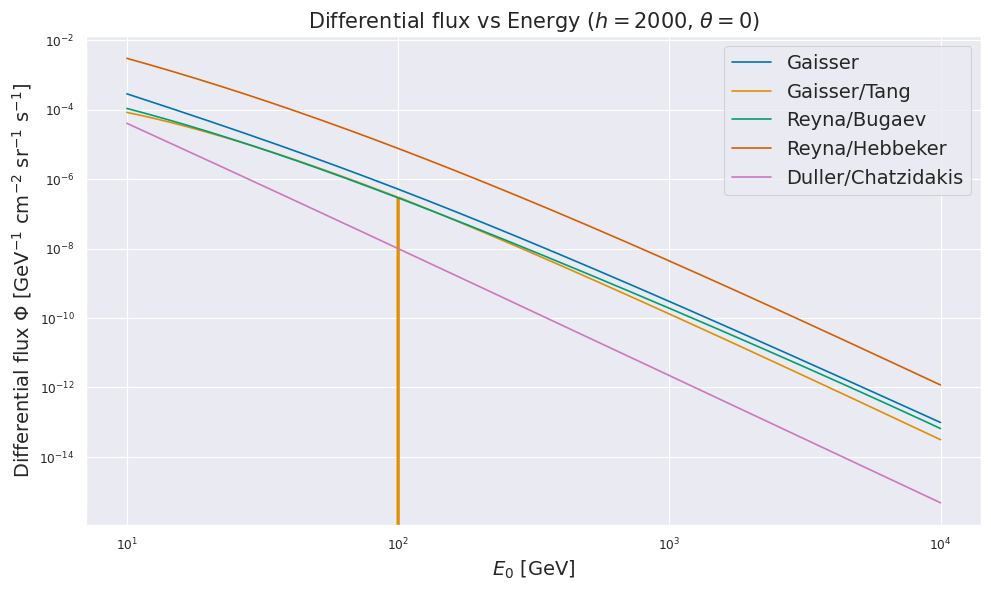

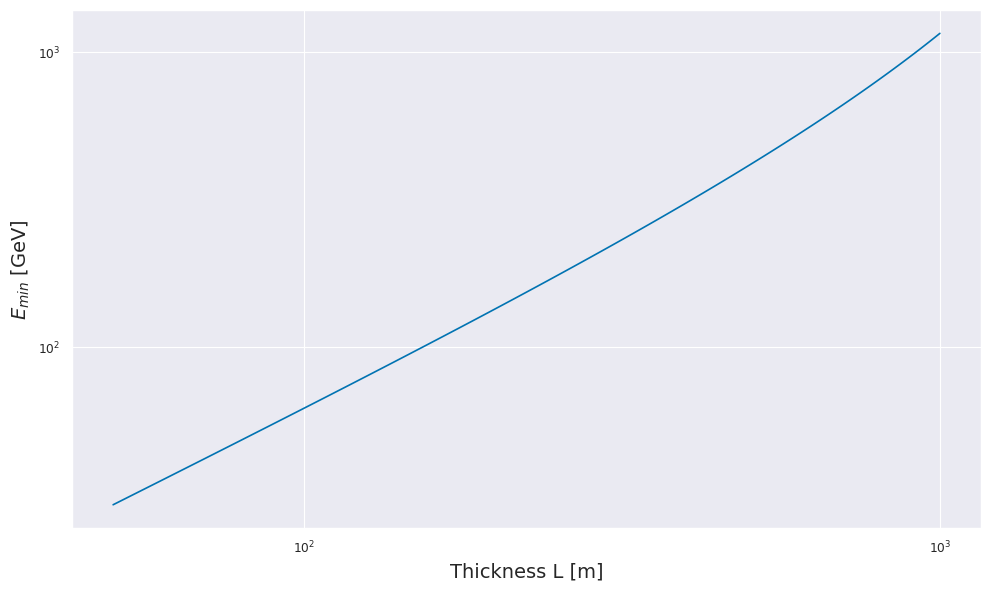

/tmp/ipython-input-1737574898.py:45: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  I, _ = quad(dif_flux, Emin, np.inf, args=(theta, h))


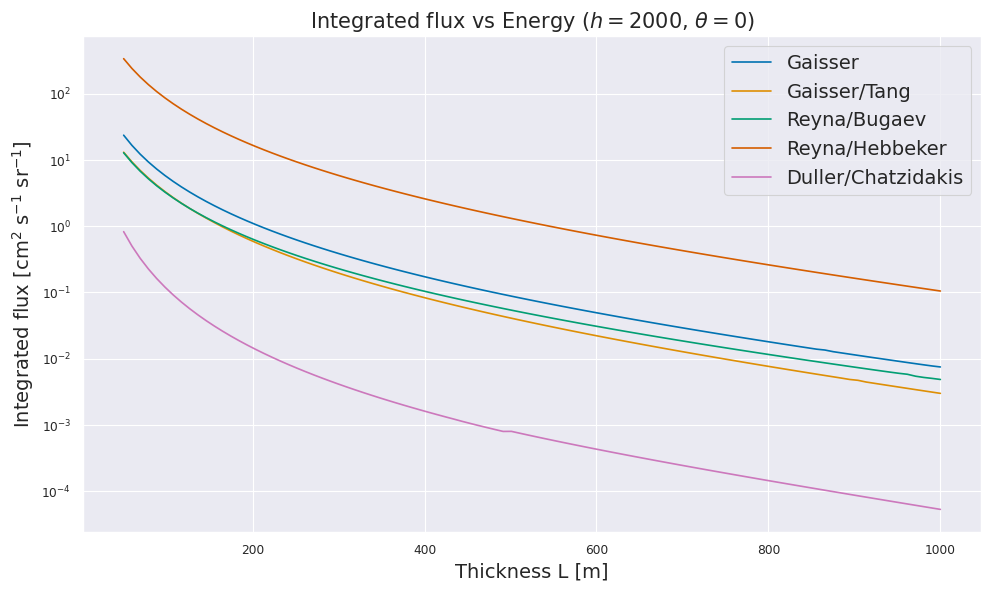

In [14]:
def main():
    theta = 0
    h = 2000
    E = np.logspace(1, 4, 1000)
    flux_G = Gaisser(E, theta, h)
    flux_GT = GaisserTang(E, theta, h)
    flux_RB = ReynaBugaev(E, theta, h)
    flux_RH = ReynaHebbeker(E, theta, h)
    flux_D = Duller(E, theta, h)

    # Differential flux vs Energy
    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(E, flux_G, label='Gaisser')
    ax.plot(E, flux_GT, label='Gaisser/Tang')
    ax.plot(E, flux_RB, label='Reyna/Bugaev')
    ax.plot(E, flux_RH, label='Reyna/Hebbeker')
    ax.plot(E, flux_D, label='Duller/Chatzidakis')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlabel(r'$E_0$ [GeV]', fontsize=14)
    ax.set_ylabel(r'Differential flux $\Phi$ [GeV$^{-1}$ cm$^{-2}$ sr$^{-1}$ s$^{-1}$]', fontsize=14)
    ax.set_title(rf'Differential flux vs Energy ($h={h}$, $\theta ={theta}$)', fontsize=15)
    ax.legend(fontsize=14)
    fig.tight_layout()
    fig.savefig('Differential_flux.pdf', dpi=300)
    plt.show()

    L = np.linspace(50, 1000, 100)
    E_min = np.array([Emin(l) for l in L])

    # Minimum energies to cross a section of thickness L
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(L, E_min)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlabel('Thickness L [m]', fontsize=14)
    ax.set_ylabel(r'$E_{min}$ [GeV]', fontsize=14)
    fig.tight_layout()
    fig.savefig('Minimum_energies.pdf', dpi=300)
    plt.show()

    Int_flux_G = np.array([Integrate_flux(Gaisser, Em, theta, h) for Em in E_min])
    Int_flux_G *= 24 * 3600  # Seconds to Days

    Int_flux_GT = np.array([Integrate_flux(GaisserTang, Em, theta, h) for Em in E_min])
    Int_flux_GT *= 24 * 3600  # Seconds to Days

    Int_flux_RB = np.array([Integrate_flux(ReynaBugaev, Em, theta, h) for Em in E_min])
    Int_flux_RB *= 24 * 3600  # Seconds to Days

    Int_flux_RH = np.array([Integrate_flux(ReynaHebbeker, Em, theta, h) for Em in E_min])
    Int_flux_RH *= 24 * 3600  # Seconds to Days

    Int_flux_D = np.array([Integrate_flux(Duller, Em, theta, h) for Em in E_min])
    Int_flux_D *= 24 * 3600  # Seconds to Days

    # Integrated flux
    fig, ax = plt.subplots(figsize= (10, 6))
    ax.plot(L, Int_flux_G, label ='Gaisser')
    ax.plot(L, Int_flux_GT, label ='Gaisser/Tang')
    ax.plot(L, Int_flux_RB, label ='Reyna/Bugaev')
    ax.plot(L, Int_flux_RH, label ='Reyna/Hebbeker')
    ax.plot(L, Int_flux_D, label ='Duller/Chatzidakis')
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlabel('Thickness L [m]', fontsize=14)
    ax.set_ylabel(r'Integrated flux [cm$^2$ s$^{-1}$ sr$^{-1}$]', fontsize=14)
    ax.set_title(rf'Integrated flux vs Energy ($h={h}$, $\theta ={theta}$)', fontsize=15)
    ax.legend(fontsize=14)
    fig.tight_layout()
    fig.savefig('Integrated_flux.pdf', dpi=300)
    plt.show()

main()

In [15]:
# Comparing the differential flux vs energy with respect to the angle (ANIMATION)
def DifFlux_vs_angle():
    h = 0
    theta_deg = np.arange(0, 91)
    theta_rad = np.deg2rad(theta_deg)
    E = np.logspace(1, 4, 1000)
    flux_G = np.array([Gaisser(E, theta, h) for theta in theta_rad])
    flux_GT = np.array([GaisserTang(E, theta, h) for theta in theta_rad])
    flux_RB = np.array([ReynaBugaev(E, theta, h) for theta in theta_rad])
    flux_RH = np.array([ReynaHebbeker(E, theta, h) for theta in theta_rad])
    flux_D = np.array([Duller(E, theta, h) for theta in theta_rad])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(E[0], E[-1])
    ax.set_ylim(1e-15, 1e-3)

    line_G, = ax.plot([], [], label='Gaisser')
    line_GT, = ax.plot([], [], label='Gaisser/Tang')
    line_RB, = ax.plot([], [], label='Reyna/Bugaev')
    line_RH, = ax.plot([], [], label='Reyna/Hebbeker')
    line_D, = ax.plot([], [], label='Duller/Chatzidakis')
    title = ax.set_title("", fontsize=15)

    ax.set_xlabel(r"$E_0$ [GeV]", fontsize=14)
    ax.set_ylabel(r"Differential flux $\Phi$ [GeV$^{-1}$ cm$^{-2}$ sr$^{-1}$ s$^{-1}$]", fontsize=14)
    ax.legend(fontsize=14)
    fig.tight_layout()

    def update(frame):
        line_G.set_data(E, flux_G[frame])
        line_GT.set_data(E, flux_GT[frame])
        line_RB.set_data(E, flux_RB[frame])
        line_RH.set_data(E, flux_RH[frame])
        line_D.set_data(E, flux_D[frame])

        title.set_text(rf"Differential flux vs Energy ($h={h}$, $\theta ={theta_deg[frame]}$)")

        return line_G, line_RB, title

    anim = FuncAnimation(fig,
                         update,
                         frames=len(theta_deg),
                         interval=100,
                         blit=True)

    writer = FFMpegWriter(fps= 10)
    anim.save("difflux_theta.mp4", writer=writer)

    plt.close()

DifFlux_vs_angle()

In [19]:
# Comparing the integrated flux vs thickness with respect to the angle (ANIMATION)
def IntFlux_vs_angle():
    h = 0
    theta_deg = np.arange(0, 91)
    theta_rad = np.deg2rad(theta_deg)

    L = np.linspace(50, 1000, 100)
    E_min = np.array([Emin(l) for l in L])

    Int_flux_G = np.array([[Integrate_flux(Gaisser, Em, theta, h) for Em in E_min] for theta in theta_rad])
    Int_flux_G *= 24 * 3600  # Seconds to Days

    Int_flux_RB = np.array([[Integrate_flux(ReynaBugaev, Em, theta, h) for Em in E_min] for theta in theta_rad])
    Int_flux_RB *= 24 * 3600  # Seconds to Days

    Int_flux_RH = np.array([[Integrate_flux(ReynaHebbeker, Em, theta, h) for Em in E_min] for theta in theta_rad])
    Int_flux_RH *= 24 * 3600  # Seconds to Days

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(L[0], L[-1])
    ax.set_ylim(1e-3, 1e2)

    line_G, = ax.plot([], [], label='Gaisser')
    line_RB, = ax.plot([], [], label='Reyna/Bugaev')
    line_RH, = ax.plot([], [], label='Reyna/Hebbeker')

    title = ax.set_title("", fontsize=15)

    ax.set_xlabel(r"Thickness L [m]", fontsize=14)
    ax.set_ylabel(r"Integrated flux $\Phi$ [GeV$^{-1}$ cm$^{-2}$ sr$^{-1}$ s$^{-1}$]", fontsize=14)
    ax.legend(fontsize=14)
    fig.tight_layout()

    def update(frame):
        line_G.set_data(L, Int_flux_G[frame])
        line_RB.set_data(L, Int_flux_RB[frame])
        line_RH.set_data(L, Int_flux_RH[frame])

        title.set_text(rf"Integrated flux vs Thickness ($h={h}$, $\theta ={theta_deg[frame]}$)")

        return line_G, line_RB, line_RH, title

    anim = FuncAnimation(fig,
                         update,
                         frames=len(theta_deg),
                         interval=100,
                         blit=True)

    writer = FFMpegWriter(fps= 10)
    anim.save("intflux_theta.mp4", writer=writer)

    plt.close()

IntFlux_vs_angle()

Continuous Slowing Down Approximation (CSDA) range:
\begin{equation*}
    R = \int \left( -\frac{dE}{ds} \right)^{-1}dE
\end{equation*}

This quantity provides an approximation by the assumption that the particle losses energy continuously. It is the mean range necessary for the particle to stop completely.

\begin{equation*}
    \frac{dR}{dE} = \left( -\frac{dE}{ds} \right)^{-1}
\end{equation*}

\begin{equation*}
    \frac{dE}{ds} = \left( -\frac{dR}{dE} \right)^{-1}
\end{equation*}

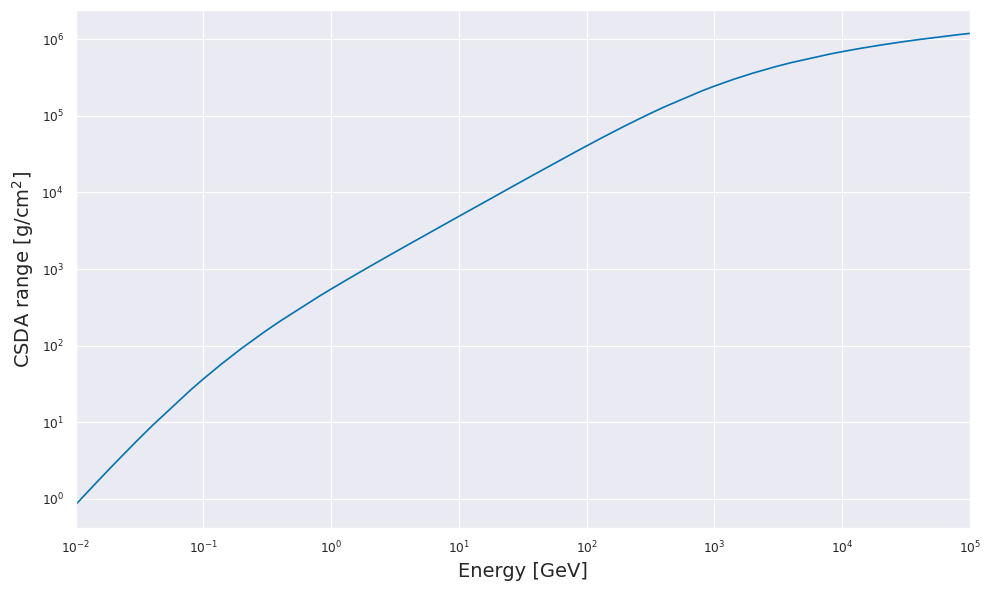

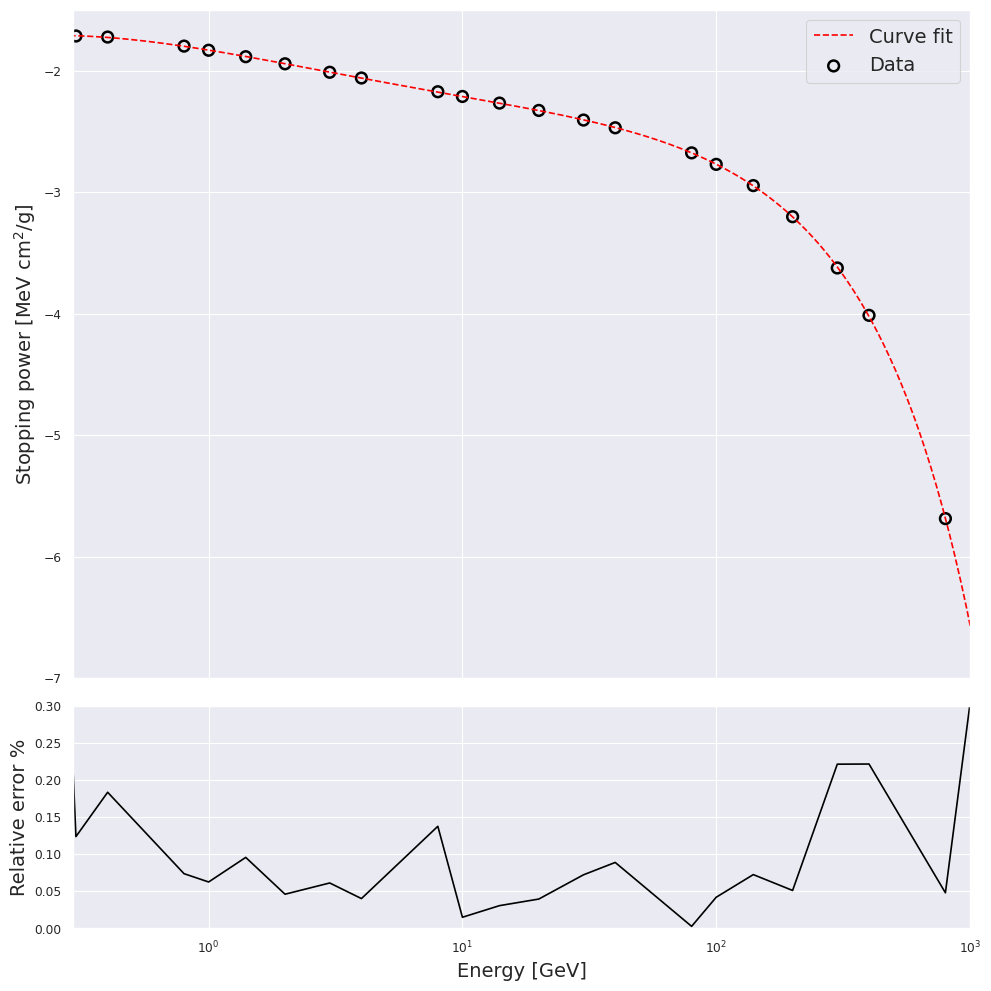

l0 = 0.2629 +/- 0.0002
l1 = 0.0808 +/- 0.0004
l2 = 0.0253 +/- 0.0009
l3 = -0.0373 +/- 0.0007
l4 = 0.0135 +/- 0.0001


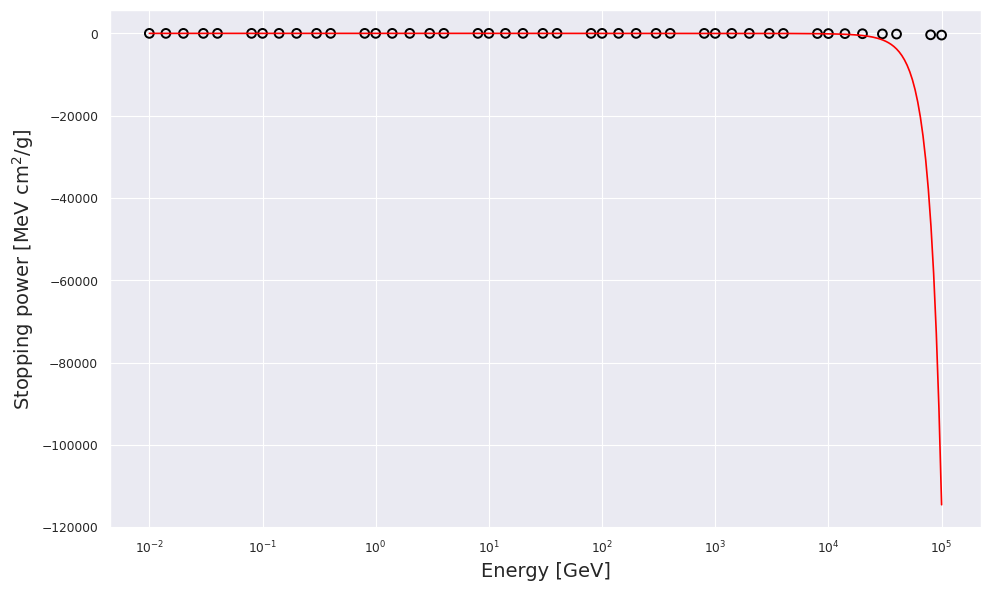

In [21]:
#
def func_fit(E, l0, l1, l2, l3, l4):
    y = np.log10(E)

    return l0 + l1*y + l2*y**2 + l3*y**3 + l4*y**4

# Energy [GeV]
E = np.array([10e-3, 14e-3, 20e-3, 30e-3, 40e-3, 80e-3, 100e-3, 140e-3, 200e-3, 300e-3, 400e-3, 800e-3,
              1.0, 1.4, 2.0, 3.0, 4.0, 8.0, 10.0, 14.0, 20.0, 30.0, 40.0, 80.0, 100.0, 140.0, 200.0, 300.0, 400.0, 800.0,
              1.0e3, 1.4e3, 2.0e3, 3.0e3, 4.0e3, 8.0e3, 10.0e3, 14.0e3, 20.0e3, 30.0e3, 40.0e3, 80.0e3, 100.0e3])
# CSDA range [g/cm2]
R = np.array([8.343e-1, 1.520, 2.835, 5.649, 9.073, 2.655e1, 3.664e1, 5.822e1, 9.232e1, 1.506e2, 2.089e2, 4.360e2,
              5.460e2, 7.607e2, 1.073e3, 1.577e3, 2.066e3, 3.945e3, 4.855e3, 6.637e3, 9.242e3, 1.346e4, 1.755e4, 3.305e4, 4.038e4, 5.435e4, 7.382e4, 1.030e5, 1.290e5, 2.112e5,
              2.434e5, 2.970e5, 3.594e5, 4.361e5, 4.933e5, 6.376e5, 6.853e5, 7.580e5, 8.356e5, 9.241e5, 9.871e5, 1.139e6, 1.187e6])

# Minimum ionization energy 293 MeV
Emin = 293e-3

# Graphic for the CSDA range with respect to the energy
fig, ax =plt.subplots(figsize=(10, 6))
ax.plot(E, R)
ax.set_xlabel('Energy [GeV]', fontsize=14)
ax.set_ylabel(r'CSDA range [g/cm$^2$]', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(E.min(), E.max())
fig.tight_layout()
plt.show()

# Calculate the stopping power in MeV cm2/g
dR_dE = np.gradient(R, E)
S = -1/dR_dE
S *= 1000

# Do the curve fit with Emin < E < 1000 GeV
logS = np.log10(-S)
mask = (E > Emin) & (E < 1e3)
par, cov = curve_fit(func_fit, E[mask], logS[mask])
l0, l1, l2, l3, l4 = par
dl0, dl1, dl2, dl3, dl4 = np.sqrt(np.diag(cov))

# Apply the fit to a linspace to plot it and it's relative error
E_fit = np.logspace(np.log10(E.min()), np.log10(E.max()), 300)
S_fit = -10**(func_fit(E_fit, *par))
err = np.abs((-10**func_fit(E, *par) - S) / S)

# Graphic for the curve fit and the data
fig, (ax1, ax2) =plt.subplots(2, 1, figsize=(10, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(E_fit, S_fit, color='red', linestyle='--', label='Curve fit')
ax1.scatter(E[mask], S[mask], marker='o', s=60, facecolors='none', edgecolors='black', linewidths=1.8, label='Data')
ax1.set_ylabel(r'Stopping power [MeV cm$^2$/g]', fontsize=14)
ax1.set_xscale('log')
ax1.set_xlim(Emin, 1e3)
ax1.set_ylim(-7, -1.5)
ax1.tick_params(labelbottom=False)
ax1.legend(fontsize=14)

# Graphic for the relative error of the curve fit
ax2.plot(E, err*100, color='black')
ax2.set_xlabel('Energy [GeV]', fontsize=14)
ax2.set_ylabel('Relative error %', fontsize=14)
ax2.set_xscale('log')
ax2.set_xlim(Emin, 1e3)
ax2.set_ylim(0, 0.3)
fig.tight_layout()
plt.show()

# Show the parameters and their deviations
print(f'l0 = {l0:.4f} +/- {dl0:.4f}')
print(f'l1 = {l1:.4f} +/- {dl1:.4f}')
print(f'l2 = {l2:.4f} +/- {dl2:.4f}')
print(f'l3 = {l3:.4f} +/- {dl3:.4f}')
print(f'l4 = {l4:.4f} +/- {dl4:.4f}')

# Graphic with all data and the curve fit
fig, ax =plt.subplots(figsize=(10, 6))
ax.plot(E_fit, S_fit, color='red')
ax.scatter(E, S, marker='o', s=40, facecolors='none', edgecolors='black', linewidths=1.4, label='Data')
ax.set_xlabel('Energy [GeV]', fontsize=14)
ax.set_ylabel(r'Stopping power [MeV cm$^2$/g]', fontsize=14)
ax.set_xscale('log')
ax.set_title('')
fig.tight_layout()
plt.show()